# Comparative analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from dlroms import * 

import os
import sys
sys.path.insert(0, '..')
from src.utils import *
from src.activations import *

### Load (and display table of) comparison analysis

In [2]:
# Load and display all table
analysis_raw = load_analysis('../results/comparison_analysis.obj')
analysis = pd.DataFrame(analysis_raw)
analysis['training_efficiency'] = analysis['elapsed_time'] / analysis['epochs']
analysis

,experiment,act_name,act_parameter,act_sharpness,initialization,model_name,mse,mre,elapsed_time,epochs,monitors,training_efficiency
0,rod,hypact,0.100679,0.5,standard,ae,473.543823,0.002971,141.403513,1500,"{'loss_train': [15125.5986328125, 2541.0451660...",0.094269
1,rod,hypact,0.100679,0.5,standard,sae,424.272400,0.002739,123.227897,1500,"{'loss_train': [7441.6728515625, 2007.06140136...",0.082152
2,rod,hypact,0.100679,0.5,standard,sbae,149.716064,0.001668,4213.262136,1500,"{'loss_train': [347.4922180175781, 27.67978858...",2.808841
3,rod,hypact,0.100679,0.5,standard,soae,337.915436,0.002288,1209.474211,1431,"{'loss_train': [404.2274169921875, 42.69881820...",0.845195
4,rod,hypact,0.100679,0.5,eys,ae,127.863503,0.001427,139.613512,1500,"{'loss_train': [7.5754008293151855, 5.78315401...",0.093076
...,...,...,...,...,...,...,...,...,...,...,...,...
91,gaussian,leaky,5.000000,3.0,standard,soae,0.018602,0.021538,1690.953518,1500,"{'loss_train': [22.147235870361328, 6.13079833...",1.127302
92,gaussian,leaky,5.000000,3.0,eys,ae,0.004493,0.009604,92.010358,1500,"{'loss_train': [23.40103530883789, 22.91641807...",0.061340
93,gaussian,leaky,5.000000,3.0,eys,sae,0.002831,0.008139,75.360657,1500,"{'loss_train': [4.60595703125, 3.4736845493316...",0.050240
94,gaussian,leaky,5.000000,3.0,eys,sbae,0.007300,0.013966,5243.934211,1500,"{'loss_train': [4.797812461853027, 3.997354745...",3.495956


In [3]:
analysis[analysis['act_name'] == 'leaky']['act_parameter']

16    0.833333
17    0.833333
18    0.833333
19    0.833333
20    0.833333
21    0.833333
22    0.833333
23    0.833333
24    5.000000
25    5.000000
26    5.000000
27    5.000000
28    5.000000
29    5.000000
30    5.000000
31    5.000000
48    0.833333
49    0.833333
50    0.833333
51    0.833333
52    0.833333
53    0.833333
54    0.833333
55    0.833333
56    5.000000
57    5.000000
58    5.000000
59    5.000000
60    5.000000
61    5.000000
62    5.000000
63    5.000000
80    0.833333
81    0.833333
82    0.833333
83    0.833333
84    0.833333
85    0.833333
86    0.833333
87    0.833333
88    5.000000
89    5.000000
90    5.000000
91    5.000000
92    5.000000
93    5.000000
94    5.000000
95    5.000000
Name: act_parameter, dtype: float64

In [4]:
for exp_name in ('rod', 'gaussian', 'shield'):
    # select ROD experiment and EYS initialization
    sae_analysis = analysis[(analysis['experiment'] == exp_name) * (analysis['initialization'] == 'eys')]
    sae_analysis.pop('act_parameter')
    sae_analysis.pop('elapsed_time')
    sae_analysis.pop('monitors')
    sae_analysis.pop('epochs')
    sae_analysis.pop('training_efficiency')
    sae_analysis.pop('initialization')
    sae_analysis.pop('experiment')
    # Print table in simplified latex format
    print('% Tabella raw, experiment ->', exp_name.upper())
    print(sae_analysis.to_latex(index=False,
                    formatters={"name": str.upper},
                    float_format="{:.2e}".format))


% Tabella raw, experiment -> ROD
\begin{tabular}{lrlrr}
\toprule
act_name & act_sharpness & model_name & mse & mre \\
\midrule
hypact & 5.00e-01 & ae & 1.28e+02 & 1.43e-03 \\
hypact & 5.00e-01 & sae & 1.09e+02 & 1.43e-03 \\
hypact & 5.00e-01 & sbae & 4.67e+01 & 8.26e-04 \\
hypact & 5.00e-01 & soae & 1.27e+02 & 1.44e-03 \\
hypact & 3.00e+00 & ae & 3.31e+02 & 2.17e-03 \\
hypact & 3.00e+00 & sae & 1.24e+02 & 1.57e-03 \\
hypact & 3.00e+00 & sbae & 5.10e+01 & 8.44e-04 \\
hypact & 3.00e+00 & soae & 1.03e+02 & 1.26e-03 \\
leaky & 5.00e-01 & ae & 1.19e+02 & 1.48e-03 \\
leaky & 5.00e-01 & sae & 7.59e+01 & 1.11e-03 \\
leaky & 5.00e-01 & sbae & 6.31e+01 & 9.65e-04 \\
leaky & 5.00e-01 & soae & 1.57e+02 & 1.59e-03 \\
leaky & 3.00e+00 & ae & 9.38e+02 & 3.36e-03 \\
leaky & 3.00e+00 & sae & 1.11e+02 & 1.36e-03 \\
leaky & 3.00e+00 & sbae & 4.20e+01 & 8.46e-04 \\
leaky & 3.00e+00 & soae & 1.50e+02 & 1.63e-03 \\
\bottomrule
\end{tabular}

% Tabella raw, experiment -> GAUSSIAN
\begin{tabular}{lrlrr}
\topr

### Visualize accuracy and computational performance (figure generation)

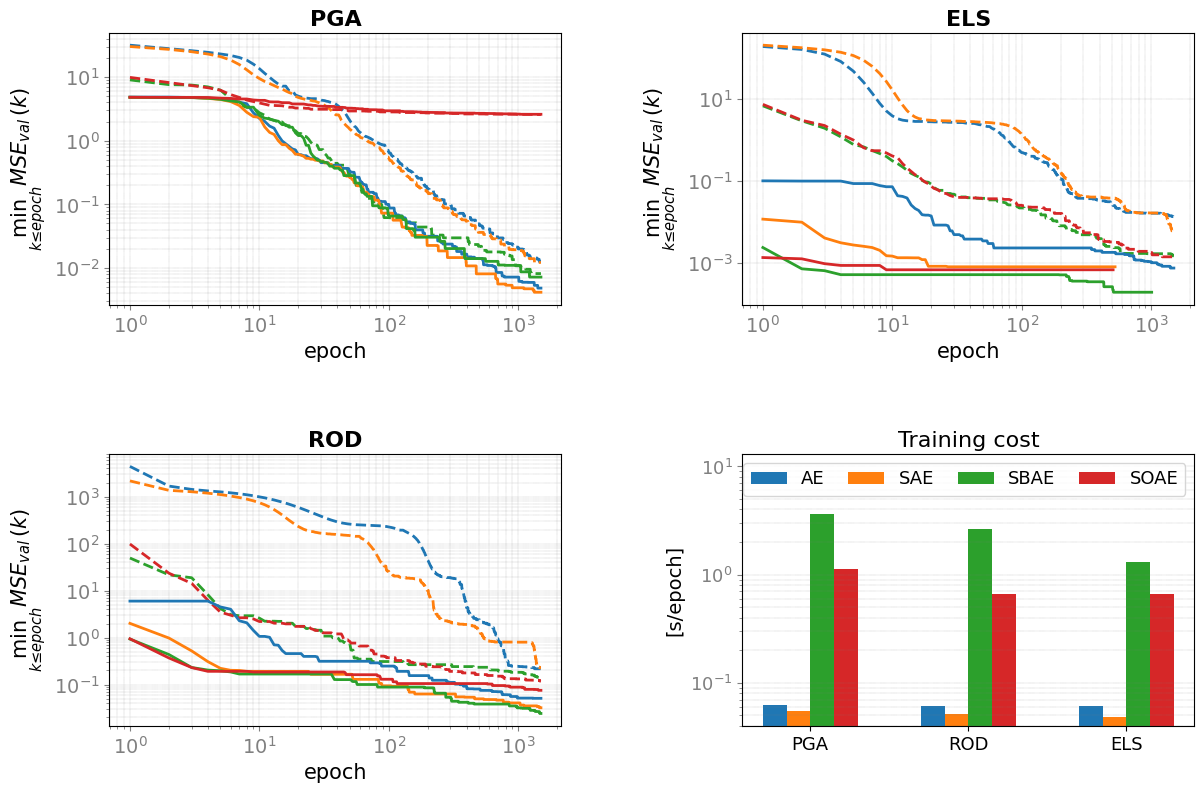

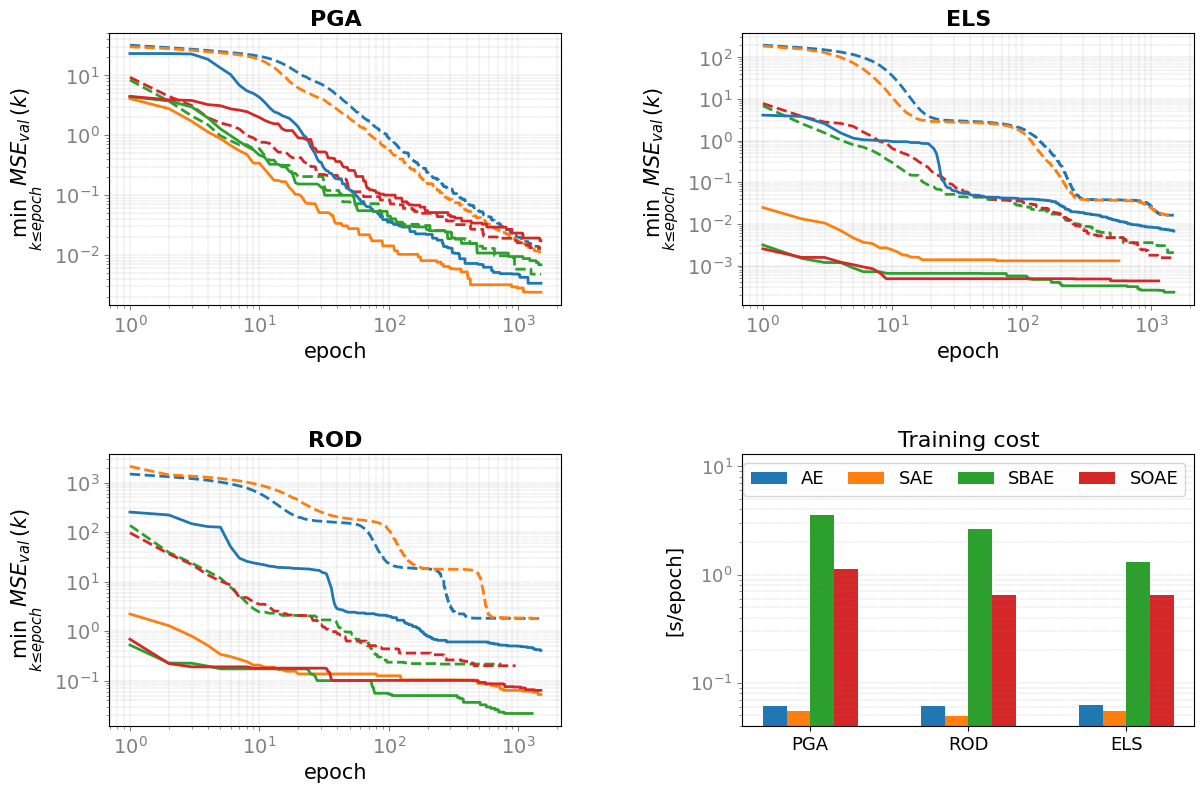

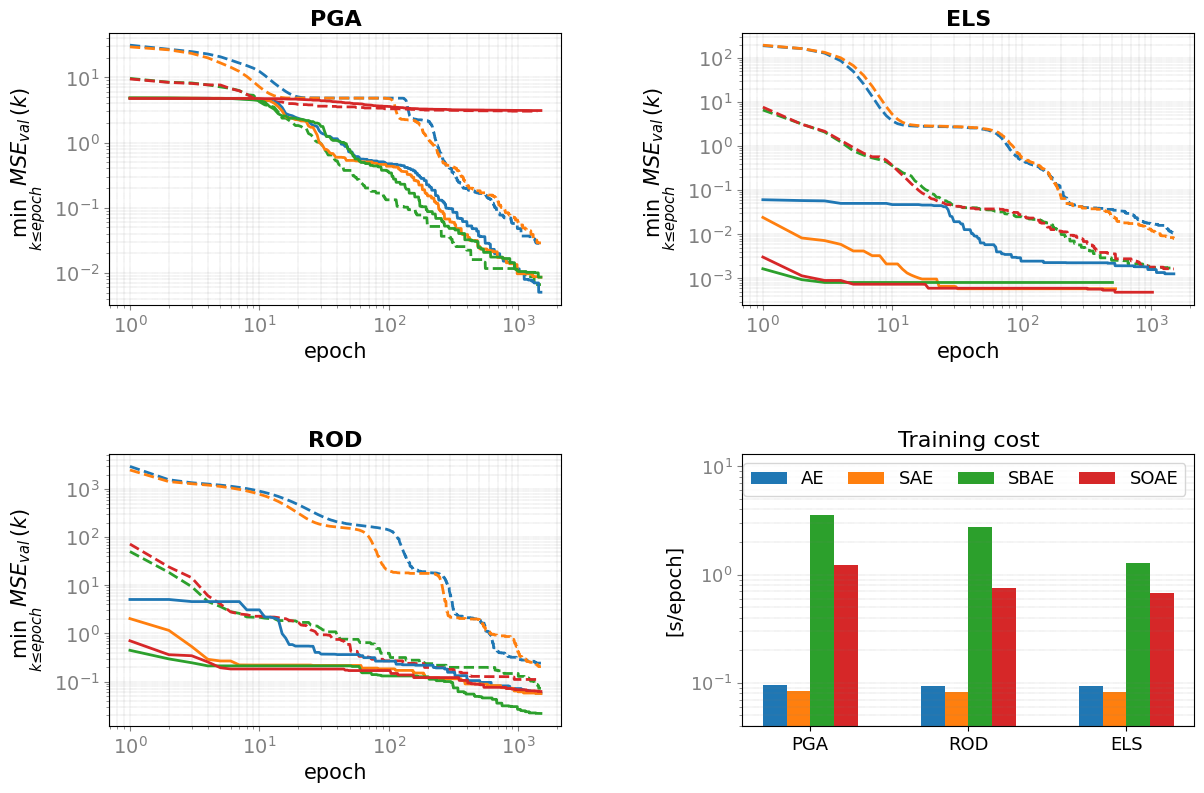

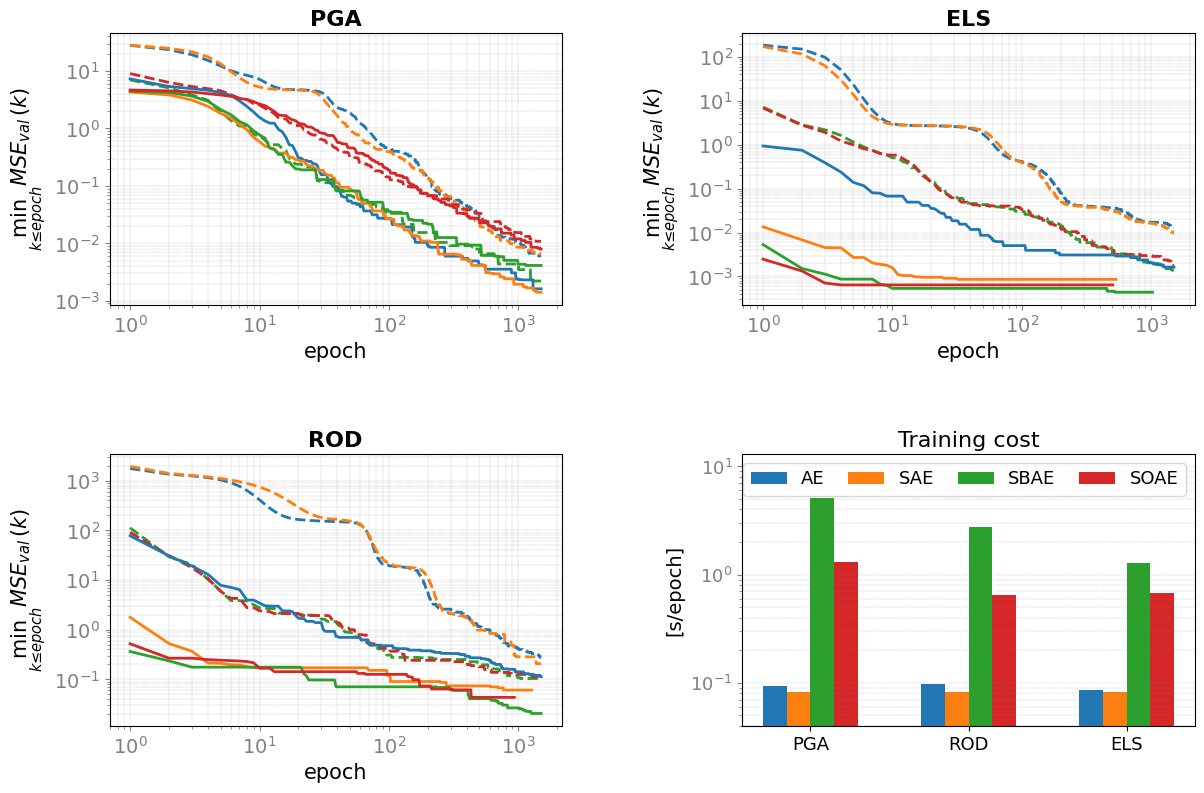

In [5]:
def visualize_comparison_compressed(act_name : str, act_param_id, figure_id : str = ''):
    fig, axs = plt.subplots(2, 2, figsize = (14,9), gridspec_kw={'width_ratios': [1, 1]})
    axs = axs.reshape((-1,))
    for idx_axs, exp_name in enumerate(('gaussian', 'shield', 'rod')):

        # Extraction
        curr_analysis = analysis[(analysis['experiment'] == exp_name) * (analysis['act_name'] == act_name)]
        curr_analysis = curr_analysis[curr_analysis['act_parameter'] == np.unique(curr_analysis['act_parameter'])[act_param_id]]
        cmap = plt.get_cmap('tab10')
        standard = list(curr_analysis[curr_analysis['initialization'] == 'standard']['monitors'])
        eys = list(curr_analysis[curr_analysis['initialization'] == 'eys']['monitors'])
        model_name = list(curr_analysis[curr_analysis['initialization'] == 'eys']['model_name'])

        # Trlevelsaining dynamics
        for idx in range(len(standard)):
            axs[idx_axs].loglog(np.arange(1, len(standard[idx]['loss_val']) + 1), np.minimum.accumulate(standard[idx]['loss_val']), linestyle = '--', color = cmap(idx), linewidth = 2)
        for idx in range(len(eys)):
            axs[idx_axs].loglog(np.arange(1, len(eys[idx]['loss_val']) + 1), np.minimum.accumulate(eys[idx]['loss_val']), color = cmap(idx), label = model_name[idx].upper(), linewidth = 2)
    
        axs[idx_axs].grid(color='grey', which = 'both', linestyle=':', linewidth=0.3)
        axs[idx_axs].xaxis.set_tick_params(labelsize = 14, which = 'both')
        axs[idx_axs].yaxis.set_tick_params(labelsize = 14, which = 'both')
        axs[idx_axs].set_xlabel('epoch', fontsize = 15)
        axs[idx_axs].set_ylabel('$\min_{k \leq epoch} MSE_{val}(k)$', fontsize = 15)
        axs[idx_axs].tick_params(axis='x', which = 'both', colors='grey')
        axs[idx_axs].tick_params(axis='y', which = 'both', colors='grey')
        def get_curr_title(exp_name):
            if exp_name == 'gaussian':
                return 'PGA'
            elif exp_name == 'rod':
                return 'ROD'
            elif exp_name == 'shield':
                return 'ELS'
            else:
                raise ValueError
        axs[idx_axs].set_title(get_curr_title(exp_name), fontsize = 16, fontweight='bold', pad = 5)

    # Computational efficiency
    efficiency_hist = dict()
    experiment_names = np.unique(np.array(analysis['experiment']))
    model_names = np.unique(np.array(curr_analysis['model_name']))
    for model_name in model_names:
        efficiency_hist[model_name] = list()
    for exp_name in experiment_names:
        curr_analysis = analysis[(analysis['experiment'] == exp_name) * (analysis['act_name'] == act_name)]
        curr_analysis = curr_analysis[curr_analysis['act_parameter'] == np.unique(curr_analysis['act_parameter'])[act_param_id]]
        for model_name in model_names:
            cond_stat = curr_analysis['model_name'] == model_name
            curr_eff = np.mean(curr_analysis[cond_stat]['training_efficiency'])
            efficiency_hist[model_name].append(curr_eff)
    cmap = plt.get_cmap('tab10')
    axs[-1].grid(color='grey', which = 'both', axis = 'y', linestyle=':', linewidth=0.3)
    
    width = 0.15
    multiplier = 0
    exp_range = np.arange(len(experiment_names))

    for attribute, measurement in efficiency_hist.items():
        offset = width * multiplier
        axs[-1].bar(exp_range + offset, measurement, width, label=attribute.upper())
        multiplier += 1

    axs[-1].legend(ncols = 4, fontsize = 13, columnspacing = 1.3)
    axs[-1].set_ylabel('[s/epoch]', fontsize = 14)
    axs[-1].set_xticks(exp_range + 1.5 * width, [get_curr_title(exp_name) for exp_name in experiment_names])
    axs[-1].xaxis.set_tick_params(labelsize = 13)
    axs[-1].yaxis.set_tick_params(labelsize = 13)
    plt.yscale(value = 'log')
    axs[-1].set_ylim([4e-2, 1.3e1])
    axs[-1].set_title('Training cost', fontsize = 16, pad = 5)
    axs[-1].tick_params(axis='y', which = 'both', colors='grey')

    # Adjust subplots
    plt.subplots_adjust(wspace = 0.4, hspace = 0.55)

    # Save figures
    savepath = os.path.join('..', 'results')
    if not os.path.exists(savepath):
        os.makedirs(savepath)
    plt.savefig(os.path.join(savepath, 'comparison' + figure_id + '.png'), bbox_inches='tight')


# Call function for visualization
visualize_comparison_compressed(act_name = 'leaky', act_param_id = 0)
visualize_comparison_compressed(act_name = 'leaky', act_param_id = 1, figure_id = '_suppl1')
visualize_comparison_compressed(act_name = 'hypact', act_param_id = 0, figure_id = '_suppl2')
visualize_comparison_compressed(act_name = 'hypact', act_param_id = 1, figure_id = '_suppl3')